# **Assignment 7 — Burmese Polarization Classification**

**Instructor**: Dr. Ye Kyaw Thu

**Class**: AIE-F (Batch-2)

**Submission**: Group-4 

**Date**:

---

## POLAR Task 1: Polarization Classification

## Traditional Machine Learning Approaches

This notebook experiments with traditional machine learning algorithms
for binary polarization classification using the myPolar dataset.

The following classifiers are evaluated:

- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Stochastic Gradient Descent (SGD)
- Linear Support Vector Machine (Linear SVM)

For text representation, the following approaches are compared:

- Unigram Count
- Unigram TF-IDF
- Bigram Count
- Bigram TF-IDF

The performance of the models is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

## 1. Dataset

The input dataset is the prepared Task 1 polarization dataset.

Task 1 is a binary classification problem:

- `0` = Non-polarized
- `1` = Polarized

The dataset has been prepared from the merged myPolar annotation data.
The `id` column was removed before model training because it is only an
identifier and does not contain linguistic information.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [15]:
from pathlib import Path
import pandas as pd

DATA_FILE = Path(
    "/home/thant_syn/exp/polar/processed/task1_polarization_no_id.txt"
)

rows = []

with open(DATA_FILE, "r", encoding="utf-8") as f:
    for line_num, line in enumerate(f, start=1):
        line = line.rstrip("\n\r")

        if not line.strip():
            continue

        # Split at the LAST | because the label is the final field
        parts = line.rsplit("|", 1)

        if len(parts) != 2:
            print(f"Skipping malformed line {line_num}")
            continue

        text, label = parts

        rows.append({
            "text": text.strip(),
            "label": label.strip()
        })

df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)
df.head()

Skipping malformed line 134
Skipping malformed line 135
Skipping malformed line 174
Skipping malformed line 175
Skipping malformed line 176
Skipping malformed line 177
Skipping malformed line 474
Skipping malformed line 475
Skipping malformed line 486
Skipping malformed line 487
Skipping malformed line 2125
Skipping malformed line 2126
Skipping malformed line 2127
Skipping malformed line 2128
Skipping malformed line 2129
Skipping malformed line 2130
Skipping malformed line 2131
Skipping malformed line 2132
Skipping malformed line 2133
Skipping malformed line 2134
Skipping malformed line 2135
Skipping malformed line 2136
Skipping malformed line 2137
Skipping malformed line 2138
Skipping malformed line 2139
Skipping malformed line 2140
Skipping malformed line 2141
Skipping malformed line 2145
Skipping malformed line 2146
Skipping malformed line 2147
Skipping malformed line 2357
Skipping malformed line 2358
Skipping malformed line 2727
Skipping malformed line 2728
Skipping malformed line 

,text,label
0,text,polarization
1,ကိုယ့်နိုင်ငံကြီး အေးချမ်းသွားရင် ကိုယ့်နိုင်င...,1
2,တကယ် လေ နိုင်ငံခြား သား တွေ အကုန် လုံး ကို တစ်...,1
3,ဂျပန် ထဲ မြန်မာ တွေ ဝင် လာ ပြီ ဆိုတော့ သူတို့ ...,1
4,ဒီ အကြောင်း တွေ ကို ဂျပန် လို ပြော ပြီး တင် ...,1


In [16]:
## Check data imblance

df = df.drop(0).reset_index(drop=True)

In [17]:
df.head()

,text,label
0,ကိုယ့်နိုင်ငံကြီး အေးချမ်းသွားရင် ကိုယ့်နိုင်င...,1
1,တကယ် လေ နိုင်ငံခြား သား တွေ အကုန် လုံး ကို တစ်...,1
2,ဂျပန် ထဲ မြန်မာ တွေ ဝင် လာ ပြီ ဆိုတော့ သူတို့ ...,1
3,ဒီ အကြောင်း တွေ ကို ဂျပန် လို ပြော ပြီး တင် ...,1
4,တရုတ် တွေ က ဂျပန် ကို မုန်း တယ် ပြော ပြီး ဘာလိ...,1


In [18]:
df['label'].unique

<bound method Series.unique of 0        1
1        1
2        1
3        1
4        1
        ..
10289    1
10290    1
10291    1
10292    1
10293    1
Name: label, Length: 10294, dtype: str>

In [19]:
df.tail()

,text,label
10289,ဝင်ကြည့်လိုက်တယ် အရူးတွေဖြေနေတာတွေ့တော့ ဆက်ကို...,1
10290,စောက်ရှက်မဲ့တာတော့လွန်တယ်ကွယ် ပင်စင်လွန်ဂျပုကက...,1
10291,စောက်ကျက်သရေ ကို ယုတ် တယ်,1
10292,ဒီအဖွားကြီးကန်ချပစ်,1
10293,ဘက်စုံ ဒုက္ခပေး နေ တာ ဘဲ . .,1


In [20]:
df['label'].value_counts()

label
1            5451
0            4842
အာဏာသိမ်း       1
Name: count, dtype: int64

In [21]:
# Clean the label

df = df[df["label"] != "အာဏာသိမ်း"]

df.head()

,text,label
0,ကိုယ့်နိုင်ငံကြီး အေးချမ်းသွားရင် ကိုယ့်နိုင်င...,1
1,တကယ် လေ နိုင်ငံခြား သား တွေ အကုန် လုံး ကို တစ်...,1
2,ဂျပန် ထဲ မြန်မာ တွေ ဝင် လာ ပြီ ဆိုတော့ သူတို့ ...,1
3,ဒီ အကြောင်း တွေ ကို ဂျပန် လို ပြော ပြီး တင် ...,1
4,တရုတ် တွေ က ဂျပန် ကို မုန်း တယ် ပြော ပြီး ဘာလိ...,1


In [22]:
df['label'].value_counts()

label
1    5451
0    4842
Name: count, dtype: int64

**ဒေတာက အ‌တိုင်းအတာ တစ်ခု အထိ balance ဖြစ်ပါတယ်။ ဒါကြောင့် Task1 တွင် class imbalance အတွက် ပူစရာမလိုပါ။**

In [23]:
print("Number of samples:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

Number of samples: 10293

Columns:
['text', 'label']

Missing values:
text     0
label    0
dtype: int64

Label distribution:
label
1    5451
0    4842
Name: count, dtype: int64


## 3. Data Cleaning

Before training, we check for:

1. Missing text
2. Missing labels
3. Empty text
4. Invalid labels
5. Duplicate samples

These checks are important because malformed data can affect the
performance of the classification models.

In [24]:
# Remove rows with missing text or label
df = df.dropna(subset=["text", "label"]).copy()

# Convert text to string
df["text"] = df["text"].astype(str).str.strip()

# Convert labels to integers
df["label"] = df["label"].astype(int)

# Remove empty text
df = df[df["text"] != ""]

# Keep only valid binary labels
df = df[df["label"].isin([0, 1])]

# Remove exact duplicates
df = df.drop_duplicates(subset=["text", "label"])

df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (10245, 2)


In [25]:
df.head()

,text,label
0,ကိုယ့်နိုင်ငံကြီး အေးချမ်းသွားရင် ကိုယ့်နိုင်င...,1
1,တကယ် လေ နိုင်ငံခြား သား တွေ အကုန် လုံး ကို တစ်...,1
2,ဂျပန် ထဲ မြန်မာ တွေ ဝင် လာ ပြီ ဆိုတော့ သူတို့ ...,1
3,ဒီ အကြောင်း တွေ ကို ဂျပန် လို ပြော ပြီး တင် ...,1
4,တရုတ် တွေ က ဂျပန် ကို မုန်း တယ် ပြော ပြီး ဘာလိ...,1


In [26]:
print("Final label distribution:")
print(df["label"].value_counts())

print("\nLabel proportions:")
print(df["label"].value_counts(normalize=True))

Final label distribution:
label
1    5429
0    4816
Name: count, dtype: int64

Label proportions:
label
1    0.529917
0    0.470083
Name: proportion, dtype: float64


## 4. Train / Validation / Test Split

The dataset is divided into three subsets:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

Stratified splitting is used so that the proportion of polarized and
non-polarized samples is approximately maintained across the splits.

The test set is kept separate until the final evaluation.

In [27]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

# First: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second: split temporary into 15% validation and 15% test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))
print("Test samples:", len(X_test))

Training samples: 7171
Validation samples: 1537
Test samples: 1537


## 5. Text Vectorization

ဆရာ အတန်းထဲမှာ CountVectorizer + TfidfTransformer, with unigram and bigram representations နဲ့ ပြသွားတဲ့ တစ်ခုပါ။

Traditional machine learning algorithms cannot directly process raw
text. Therefore, the text must first be converted into numerical
features.

Two types of representations are investigated:

### Count Representation

Counts the occurrence of words or n-grams.

### TF-IDF Representation

Assigns higher importance to terms that are informative for a document
while reducing the influence of very common terms.

We experiment with:

- Unigram Count
- Unigram TF-IDF
- Bigram Count
- Bigram TF-IDF

In [28]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Unigram
unigram_vectorizer = CountVectorizer(
    ngram_range=(1, 1)
)

X_train_unigram = unigram_vectorizer.fit_transform(X_train)
X_valid_unigram = unigram_vectorizer.transform(X_valid)
X_test_unigram = unigram_vectorizer.transform(X_test)

# Bigram
bigram_vectorizer = CountVectorizer(
    ngram_range=(1, 2)
)

X_train_bigram = bigram_vectorizer.fit_transform(X_train)
X_valid_bigram = bigram_vectorizer.transform(X_valid)
X_test_bigram = bigram_vectorizer.transform(X_test)

print("Unigram shape:", X_train_unigram.shape)
print("Bigram shape:", X_train_bigram.shape)

Unigram shape: (7171, 2945)
Bigram shape: (7171, 29285)


In [33]:
X_train_unigram, X_train_bigram

(<Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 58138 stored elements and shape (7171, 2945)>,
 <Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 118930 stored elements and shape (7171, 29285)>)

In [34]:
# Unigram TF-IDF
unigram_tfidf = TfidfTransformer()

X_train_unigram_tfidf = unigram_tfidf.fit_transform(X_train_unigram)
X_valid_unigram_tfidf = unigram_tfidf.transform(X_valid_unigram)
X_test_unigram_tfidf = unigram_tfidf.transform(X_test_unigram)

# Bigram TF-IDF
bigram_tfidf = TfidfTransformer()

X_train_bigram_tfidf = bigram_tfidf.fit_transform(X_train_bigram)
X_valid_bigram_tfidf = bigram_tfidf.transform(X_valid_bigram)
X_test_bigram_tfidf = bigram_tfidf.transform(X_test_bigram)

print("Unigram TF-IDF:", X_train_unigram_tfidf.shape)
print("Bigram TF-IDF:", X_train_bigram_tfidf.shape)

Unigram TF-IDF: (7171, 2945)
Bigram TF-IDF: (7171, 29285)


In [35]:
X_train_unigram_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58138 stored elements and shape (7171, 2945)>

## 6. Define Feature Sets

In [36]:
feature_sets = {
    "Unigram Count": (
        X_train_unigram,
        X_valid_unigram,
        X_test_unigram
    ),
    
    "Unigram TF-IDF": (
        X_train_unigram_tfidf,
        X_valid_unigram_tfidf,
        X_test_unigram_tfidf
    ),
    
    "Bigram Count": (
        X_train_bigram,
        X_valid_bigram,
        X_test_bigram
    ),
    
    "Bigram TF-IDF": (
        X_train_bigram_tfidf,
        X_valid_bigram_tfidf,
        X_test_bigram_tfidf
    )
}

print("Feature sets:")
for name in feature_sets:
    print("-", name)

Feature sets:
- Unigram Count
- Unigram TF-IDF
- Bigram Count
- Bigram TF-IDF


## 6. Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

Because polarization classification may contain class imbalance,
F1-score is particularly important when comparing models.

The validation set is used during model comparison, while the test set
is reserved for the final evaluation.

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

results = []

def evaluate_model(model, X_train, y_train, X_valid, y_valid,
                   model_name, feature_name):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_valid)
    
    results.append({
        "Model": model_name,
        "Features": feature_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred, zero_division=0),
        "Recall": recall_score(y_valid, y_pred, zero_division=0),
        "F1": f1_score(y_valid, y_pred, zero_division=0)
    })

## 7. K-Nearest Neighbors (KNN)

KNN classifies a sample according to the labels of nearby training
samples.

The reference notebook uses:

    KNeighborsClassifier(n_neighbors=5)

We use the same basic configuration here for comparison.

In [38]:
from sklearn.neighbors import KNeighborsClassifier

for feature_name, (Xtr, Xv, Xt) in feature_sets.items():
    
    model = KNeighborsClassifier(n_neighbors=5)
    
    evaluate_model(
        model,
        Xtr, y_train,
        Xv, y_valid,
        "KNN",
        feature_name
    )

print("KNN experiments completed.")

KNN experiments completed.


## Decision Tree

In [39]:
from sklearn.tree import DecisionTreeClassifier

for feature_name, (Xtr, Xv, Xt) in feature_sets.items():
    
    model = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )
    
    evaluate_model(
        model,
        Xtr, y_train,
        Xv, y_valid,
        "Decision Tree",
        feature_name
    )

print("Decision Tree experiments completed.")

Decision Tree experiments completed.


## Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

for feature_name, (Xtr, Xv, Xt) in feature_sets.items():
    
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    evaluate_model(
        model,
        Xtr, y_train,
        Xv, y_valid,
        "Random Forest",
        feature_name
    )

print("Random Forest experiments completed.")

Random Forest experiments completed.


## SGD

In [41]:
from sklearn.linear_model import SGDClassifier

for feature_name, (Xtr, Xv, Xt) in feature_sets.items():
    
    model = SGDClassifier(
        random_state=42
    )
    
    evaluate_model(
        model,
        Xtr, y_train,
        Xv, y_valid,
        "SGD",
        feature_name
    )

print("SGD experiments completed.")

SGD experiments completed.


## Linear SVM

In [42]:
from sklearn.linear_model import SGDClassifier

for feature_name, (Xtr, Xv, Xt) in feature_sets.items():
    
    model = SGDClassifier(
        random_state=42
    )
    
    evaluate_model(
        model,
        Xtr, y_train,
        Xv, y_valid,
        "SGD",
        feature_name
    )

print("SGD experiments completed.")

SGD experiments completed.


## Compare Validation Results

In [43]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Features,Accuracy,Precision,Recall,F1
0,Random Forest,Bigram Count,0.680547,0.683314,0.739558,0.710324
1,Random Forest,Bigram TF-IDF,0.675342,0.674806,0.746929,0.709038
2,SGD,Unigram Count,0.644763,0.629344,0.800983,0.704865
3,SGD,Unigram Count,0.644763,0.629344,0.800983,0.704865
4,Random Forest,Unigram TF-IDF,0.680547,0.691578,0.716216,0.703681
5,Random Forest,Unigram Count,0.677293,0.687943,0.714988,0.701205
6,SGD,Bigram TF-IDF,0.678595,0.691388,0.710074,0.700606
7,SGD,Bigram TF-IDF,0.678595,0.691388,0.710074,0.700606
8,SGD,Bigram Count,0.655172,0.661731,0.713759,0.686761
9,SGD,Bigram Count,0.655172,0.661731,0.713759,0.686761


In [44]:
print("Best validation model:")
print(results_df.iloc[0])

Best validation model:
Model        Random Forest
Features      Bigram Count
Accuracy          0.680547
Precision         0.683314
Recall            0.739558
F1                0.710324
Name: 0, dtype: object


## 8. Model Selection

The model with the strongest validation F1-score is selected for final
evaluation.

The test set has not been used during this model-selection process.

In [45]:
best_model_name = results_df.iloc[0]["Model"]
best_feature_name = results_df.iloc[0]["Features"]

print("Best model:", best_model_name)
print("Best features:", best_feature_name)

Best model: Random Forest
Best features: Bigram Count


## Final Test Evaluation

In [46]:
from scipy.sparse import vstack

best_X_train, best_X_valid, best_X_test = feature_sets[best_feature_name]

X_train_final = vstack([
    best_X_train,
    best_X_valid
])

y_train_final = pd.concat([
    y_train.reset_index(drop=True),
    y_valid.reset_index(drop=True)
])

print("Final training samples:", X_train_final.shape[0])
print("Test samples:", best_X_test.shape[0])

Final training samples: 8708
Test samples: 1537


In [49]:
from sklearn.svm import LinearSVC

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    
    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "SGD": SGDClassifier(
        random_state=42
    ),
    
    "Linear SVM": LinearSVC(
        random_state=42
    )
}

final_model = models[best_model_name]

final_model.fit(X_train_final, y_train_final)

y_test_pred = final_model.predict(best_X_test)

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Non-Polarized", "Polarized"],
    zero_division=0
))

               precision    recall  f1-score   support

Non-Polarized       0.66      0.58      0.62       722
    Polarized       0.66      0.73      0.69       815

     accuracy                           0.66      1537
    macro avg       0.66      0.66      0.66      1537
 weighted avg       0.66      0.66      0.66      1537



In [50]:
final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred, zero_division=0)
final_recall = recall_score(y_test, y_test_pred, zero_division=0)
final_f1 = f1_score(y_test, y_test_pred, zero_division=0)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_results

,Metric,Score
0,Accuracy,0.660377
1,Precision,0.664054
2,Recall,0.727607
3,F1-score,0.694379


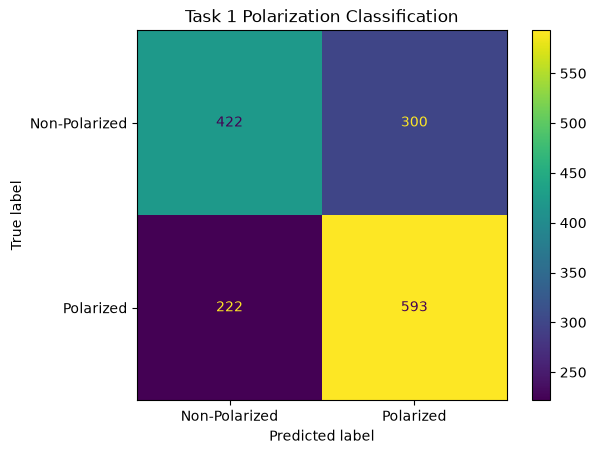

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Non-Polarized", "Polarized"]
)

plt.title("Task 1 Polarization Classification")
plt.show()

## Tune your Random Forest model

In [53]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import classification_report, accuracy_score

# rf = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [None, 20, 40, 60],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", 0.5],
#     "class_weight": [None, "balanced"]
# }

# grid_search = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     scoring="f1_macro",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train_final, y_train_final)

# print("Best parameters:", grid_search.best_params_)
# print("Best CV Macro F1:", grid_search.best_score_)

# best_model = grid_search.best_estimator_

# y_test_pred = best_model.predict(best_X_test)

# print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# print(classification_report(
#     y_test,
#     y_test_pred,
#     target_names=["Non-Polarized", "Polarized"],
#     zero_division=0
# ))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

In [56]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [20, 30, 40],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train_final, y_train_final)

print("Best parameters:", grid_search.best_params_)
print("Best CV Macro F1:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(best_X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Non-Polarized", "Polarized"],
    zero_division=0
))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.5s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.4s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.4s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=   0.7s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=   0.7s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=   0.7s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=300; total time=   1.1s
[CV] END class_weight=None, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=300; total time= 

## Tune Linear SVC

In [57]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm = LinearSVC(random_state=42)

svm_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "max_iter": [5000, 10000]
}

svm_search = GridSearchCV(
    svm,
    svm_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

svm_search.fit(X_train_final, y_train_final)

print("Best SVM parameters:", svm_search.best_params_)
print("Best CV Macro F1:", svm_search.best_score_)

svm_pred = svm_search.best_estimator_.predict(best_X_test)

print(classification_report(
    y_test,
    svm_pred,
    target_names=["Non-Polarized", "Polarized"],
    zero_division=0
))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVM parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 5000}
Best CV Macro F1: 0.6751113887505509
               precision    recall  f1-score   support

Non-Polarized       0.66      0.59      0.62       722
    Polarized       0.67      0.73      0.70       815

     accuracy                           0.67      1537
    macro avg       0.67      0.66      0.66      1537
 weighted avg       0.67      0.67      0.66      1537



---

## Neural Network-based Modelling

In [62]:
!pip install tensorflow

  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.9 MB/s  0:03:32m0:00:0100:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 3.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.1 MB/s  0:00:01 eta 0:00:01
Using cached wheel-0.48.0-py3-none-any.whl (33 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 624.4 kB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 2.4 MB/s  0:00:10m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [tensorflow]1 [tensorflow]-py]


In [63]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("TensorFlow:", tf.__version__)

I0000 00:00:1791561752.978817    1358 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791561752.996652    1358 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791561753.531464    1358 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791561759.090244    1358 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow: 2.21.0


In [66]:
# Convert the raw text to strings
X_train_text = X_train.fillna("").astype(str)
X_test_text = X_test.fillna("").astype(str)

y_train = np.asarray(y_train_final).astype("int32")
y_test_arr = np.asarray(y_test).astype("int32")

# Learn the vocabulary from training text only
MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Set sequence length based on training data
lengths = [len(seq) for seq in train_sequences]
MAX_LEN = max(1, int(np.percentile(lengths, 95)))

X_train_seq = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size:", VOCAB_SIZE)
print("Sequence length:", MAX_LEN)
print("Training shape:", X_train_seq.shape)
print("Testing shape:", X_test_seq.shape)

Vocabulary size: 20000
Sequence length: 38
Training shape: (7171, 38)
Testing shape: (1537, 38)


In [68]:
X_train_text

2092     နောက်ဆုံးမေးသွားတဲ့ မေးခွန်းနဲ့ ပတ်သက်ပြီး ISP...
9606     မ သိ လို့ မှား တာ ခွင့်လွှတ် လို့ ရ တယ် လူတိုင...
8627     အစိုးရနှင့် သွားရောက်စေ့စပ်ဆွေးနွေးခြင်းသည် အမ...
10159    ရက်စက် လိုက် တာ အလ္လာရယ် Umme AtiYah က အလ္လာဖန...
7801     လူမျိုးရေး အစွန်းရောက် ပုတ်ရဟန်းမင်ကြီး ဂရီဂို...
                               ...                        
4164     မျက်လှည့်ဆရာက အုဌ်ခဲ, စက္ကူ, ကျောက်ခဲတို့ကို မ...
3538     “လိင်ပြောင်း အကြမ်းဖက်မှု နဲ့ ပတ်သက် တဲ့ ဒေတာ ...
4825     အဲ့ မြို့ တွေ ကို ဖြတ် လေး ဖြတ် ဖြတ် ဖို့ လို တယ်
9744     ထိုသို့ လင်းသောဘောလုံး မျက်နှာတစ်ခြမ်း၏ ပုံသဏ္...
10236                             မဲမရလို့ ရူးကြတော့မှာလား
Name: text, Length: 7171, dtype: str

In [69]:
X_train_seq

array([[6980, 6981, 1297, ...,    0,    0,    0],
       [   5,   78,   16, ...,    0,    0,    0],
       [6984, 6985, 2576, ...,    0,    0,    0],
       ...,
       [ 180,  183,    4, ...,    0,    0,    0],
       [ 413,    1,    1, ...,    0,    0,    0],
       [   1,    1,    0, ...,    0,    0,    0]],
      shape=(7171, 38), dtype=int32)

In [70]:
X_train_text = [str(x) if x is not None else "" for x in X_train_text]
X_test_text = [str(x) if x is not None else "" for x in X_test_text]

In [71]:
## Build LSTM Model


model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(64, dropout=0.2)
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

E0000 00:00:1791562022.981998    1358 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
## Model training

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_seq,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15


E0000 00:00:1791562058.455442    1358 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


202/202 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.6320 - loss: 0.6338 - val_accuracy: 0.7075 - val_loss: 0.5471
Epoch 2/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8509 - loss: 0.3519 - val_accuracy: 0.7535 - val_loss: 0.5379
Epoch 3/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9217 - loss: 0.1812 - val_accuracy: 0.7702 - val_loss: 0.6058
Epoch 4/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9489 - loss: 0.1173 - val_accuracy: 0.7535 - val_loss: 0.7530
Epoch 5/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9625 - loss: 0.0832 - val_accuracy: 0.7591 - val_loss: 0.8921
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [73]:
# Evaluate on test set


y_prob = model.predict(X_test_seq, batch_size=32).ravel()
y_pred = (y_prob >= 0.5).astype("int32")

print("Test Accuracy:", accuracy_score(y_test_arr, y_pred))
print("Test Macro F1:", f1_score(
    y_test_arr, y_pred, average="macro"
))

print(classification_report(
    y_test_arr,
    y_pred,
    labels=[0, 1],
    target_names=["Non-Polarized", "Polarized"],
    zero_division=0
))

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Test Accuracy: 0.7091737150292778
Test Macro F1: 0.7090628756930537
               precision    recall  f1-score   support

Non-Polarized       0.66      0.78      0.71       722
    Polarized       0.77      0.65      0.70       815

     accuracy                           0.71      1537
    macro avg       0.71      0.71      0.71      1537
 weighted avg       0.72      0.71      0.71      1537



The BiLSTM classifier achieved a test accuracy of 70.92% and a Macro F1-score of 0.7091 on the Burmese polarization classification task. Compared with the Linear SVM baseline, which achieved approximately 0.66 Macro F1, the BiLSTM showed improved overall classification performance. Its recall for non-polarized text increased to 0.78, while recall for polarized text decreased to 0.65. These results suggest that the BiLSTM learned useful sequential patterns in the text, although further evaluation is needed to improve the balance between the two classes.


---

## **Build a stacked BiLSTM**

In [74]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

stacked_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.2)
    ),

    Bidirectional(
        LSTM(32, dropout=0.2)
    ),

    Dense(64, activation="relu"),
    Dropout(0.4),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

stacked_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

stacked_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [75]:

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_stacked = stacked_model.fit(
    X_train_seq,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.6197 - loss: 0.6569 - val_accuracy: 0.6671 - val_loss: 0.6008
Epoch 2/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.8086 - loss: 0.4390 - val_accuracy: 0.7354 - val_loss: 0.5239
Epoch 3/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9014 - loss: 0.2396 - val_accuracy: 0.7382 - val_loss: 0.5713
Epoch 4/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.9340 - loss: 0.1538 - val_accuracy: 0.7563 - val_loss: 0.6846
Epoch 5/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9501 - loss: 0.1156 - val_accuracy: 0.7061 - val_loss: 0.8270
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [76]:

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

stacked_prob = stacked_model.predict(
    X_test_seq, verbose=0
).ravel()

stacked_pred = (stacked_prob >= 0.5).astype("int32")

print("Test Accuracy:",
      accuracy_score(y_test_arr, stacked_pred))

print("Test Macro F1:",
      f1_score(y_test_arr, stacked_pred, average="macro"))

print(classification_report(
    y_test_arr,
    stacked_pred,
    labels=[0, 1],
    target_names=["Non-Polarized", "Polarized"],
    zero_division=0
))

Test Accuracy: 0.7189329863370202
Test Macro F1: 0.7187519060947591
               precision    recall  f1-score   support

Non-Polarized       0.67      0.79      0.73       722
    Polarized       0.78      0.65      0.71       815

     accuracy                           0.72      1537
    macro avg       0.73      0.72      0.72      1537
 weighted avg       0.73      0.72      0.72      1537



---